## Boosting Techniques | Assignment

Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.
  - Boosting is an ensemble learning technique in machine learning that combines multiple "weak learners" (simple models that perform only slightly better than random guessing, such as shallow decision trees) to create a single, highly accurate "strong learner."
  - How it improves weak learners:
  - Boosting works by training these weak models sequentially rather than independently. Here is how the process improves them step-by-step:
  - Initial Training:
    - The first weak learner is trained on the original dataset and makes its predictions.

  - Identifying Mistakes:
    - The algorithm evaluates the predictions and identifies where the first model made errors (misclassified data points or high residual errors).

  - Updating Focus:
    - The algorithm then adjusts the dataset for the next model. It places a higher priority on the instances that the previous model got wrong. Depending on the specific algorithm, this is done by either increasing the "weight" of misclassified samples (e.g., AdaBoost) or having the next model directly predict the residual errors of the previous one (e.g., Gradient Boosting).

  - Sequential Correction:
    - The next weak learner is trained on this updated information, effectively learning to fix its predecessor's mistakes.

  - Final Aggregation:
    - This cycle repeats for a specified number of models. In the end, all the weak learners are combined—usually through a weighted vote or sum—into one powerful model that is much more accurate and robust than any individual weak learner in the sequence.  

Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
  - The core difference between AdaBoost and Gradient Boosting lies in how they identify and correct the mistakes made by previous models in the sequence.
  - While both build models sequentially to improve accuracy, they take entirely different mathematical approaches to fix errors.
  - The Key difference:
    - AdaBoost (Adaptive Boosting) corrects mistakes by updating the weights of the data points. It makes the misclassified samples "heavier" so the next model is forced to pay more attention to them.
    - Gradient Boosting corrects mistakes by updating the target variable. Instead of changing sample weights, the new model directly tries to predict the residual errors (the difference between the actual value and the predicted value) of the previous models.
  - How Error are Handled
    - AdaBoost(adaptive Boosting):
      - Focuses on misclassified data points.
      - After each weak learner is trained
      - Misclassified samples get higher weights
      - Correctly classified samples get lower weights.
      - The next model is trained on this rewighted dataset.
    - Gradient Boosting
      - Focuses on residual errors(the difference between actual and predicted values).
      - After each model:
        - It computes the residual (errors).
        - The next model is trained to predict these residuals.
      - It uses gradient descent to mminimize a loss function.         

Question 3: How does regularization help in XGBoost?
  - Regularization in XGBoost primarily helps in preventing overfitting, making the model much more robust and better at generalizing to new, unseen data rather than just memorizing the training set.
  - Controls Tree Complexity:
    - XGBoost mathematically penalizes complex models. If a tree grows too deep or assigns extreme weights to its leaves, the regularization term increases the loss function. This forces the algorithm to prefer simpler, more conservative trees.
  - Shrinks Leaf Weights (L2 Regularization / Ridge):
    - Controlled by the lambda (or reg_lambda) hyperparameter, L2 regularization shrinks the leaf weights smoothly, preventing any single tree or feature from dominating the final prediction. This makes the model less sensitive to outliers and noise.
  - Encourages Sparsity (L1 Regularization / Lasso):
    - Controlled by the alpha (or reg_alpha) hyperparameter, L1 regularization can push the weights of less important features all the way down to exactly zero. This acts as a built-in feature selection mechanism, which is highly useful when dealing with high-dimensional datasets.
  - Strict Pruning (Gamma):
    - XGBoost uses a parameter called gamma (or min_split_loss), which acts as a threshold. A node will only split if the resulting reduction in the loss function is greater than the gamma value. This aggressively prunes branches that don't add meaningful predictive power.
  - By combining these techniques, XGBoost achieves its signature high performance without falling into the common trap of overfitting that traditional, unregularized gradient boosting faces.     

Question 4: Why is CatBoost considered efficient for handling categorical data?
  - CatBoost (which literally stands for Categorical Boosting) is considered highly efficient for categorical data because it processes these features natively during training. This completely eliminates the need for manual preprocessing steps like one-hot encoding or label encoding.
  - Eliminates the "Curse of Dimensionality":
    - Traditional methods like one-hot encoding create a new column for every unique category. For features with thousands of unique values (high cardinality), this creates massive, sparse datasets that consume huge amounts of memory and slow down training. CatBoost avoids this by keeping the categorical features in a single column.
  - Ordered Target Statistics (Target Encoding):
    - Instead of one-hot encoding, CatBoost replaces categorical values with numerical values based on the expected target value (the relationship between the category and what you are trying to predict).
  - Prevents Data Leakage:
    - Standard target encoding can lead to severe overfitting because it uses the target of a specific row to calculate its own encoded value. CatBoost solves this using an "ordered" principle—it artificially shuffles the data and calculates the target statistic for a specific row using only the rows that appear before it in the permutation.
  - Automatic Feature Combinations:
    - During the construction of the decision trees, CatBoost automatically combines multiple categorical features to create new, complex features (e.g., combining "City" and "Job Title"). This helps the model learn higher-order dependencies that individual features wouldn't show on their own.
  - Smart Handling of Low Cardinality:
    - For categorical features with only a few unique values (like Gender or Yes/No columns), CatBoost is smart enough to automatically use one-hot encoding under the hood, as this is still the most efficient method for low-cardinality data.               

Question 5: What are some real-world applications where boosting techniques are
preferred over bagging methods?
  - Boosting is generally preferred over bagging (like Random Forest) when maximizing predictive accuracy is the absolute highest priority, and when you are dealing with highly imbalanced datasets or complex, non-linear relationships.
  - While bagging primarily focuses on reducing variance (preventing overfitting), boosting actively reduces bias by sequentially pushing the limits of what the model can learn from the hardest-to-predict data points.
  - Financial Fraud Detection & Credit Scoring:
    - Fraudulent transactions or loan defaults are very rare compared to normal, everyday activity (creating a highly imbalanced dataset). Because boosting intentionally forces each new tree to focus on the mistakes of the previous ones, it becomes exceptionally good at isolating and identifying those rare, difficult-to-catch fraudulent cases.
  - Search Engine Ranking (Learning to Rank):
    - Search engines rely heavily on boosting algorithms (like LambdaMART) to determine the exact order of web pages for a given query. Boosting is highly effective at minimizing ranking errors, ensuring the most relevant link appears exactly at position #1 rather than just randomly on the first page.
  - Click-Through Rate (CTR) Prediction:
    - In online advertising, predicting whether a user will click an ad requires finding complex, hidden interactions between user demographics, the time of day, and specific ad features. Boosting algorithms handle these high-dimensional interactions incredibly well, providing the extreme precision needed for real-time bidding systems.
  - Customer Churn Prediction:
    - Companies use boosting to accurately predict which customers are likely to cancel a subscription or leave a service. The high accuracy of boosting allows businesses to precisely target retention offers (like discounts) only to those who are actually at risk of leaving, optimizing their marketing budget.
  - Medical Diagnosis and Risk Assessment:
    - When diagnosing diseases from structured patient data, the cost of a false negative (missing a disease) is incredibly high. Boosting's iterative error-correction makes it highly sensitive to subtle patterns and anomalies in patient records, improving early detection rates compared to simpler parallel models.        

In [1]:
# Question 6: Write a Python program to:
# 1.Train an AdaBoost Classifier on the Breast Cancer dataset
# 2. Print the model accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 2: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the AdaBoost Classifier
# We use 50 weak learners (decision stumps by default)
ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)

# Step 4: Make predictions on the test data
y_pred = ada_model.predict(X_test)

# Step 5: Calculate and print the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Model Accuracy: {accuracy:.4f}")

AdaBoost Model Accuracy: 0.9649


In [2]:
# Question 7: Write a Python program to:
# 1. Train a Gradient Boosting Regressor on the California Housing dataset
# 2. Evaluate performance using R-squared score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load the California Housing dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Step 2: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the Gradient Boosting Regressor
# Using 100 trees and a learning rate of 0.1
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Step 4: Make predictions on the test data
y_pred = gb_model.predict(X_test)

# Step 5: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Squared Error (MSE): 0.2940
R-squared (R2) Score: 0.7756


In [3]:
# Question 8: Write a Python program to:
# 1.Train an XGBoost Classifier on the Breast Cancer dataset
# 2.Tune the learning rate using GridSearchCV
# 3.Print the best parameters and accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 2: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Step 4: Define the parameter grid for tuning the learning rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# Step 5: Set up GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='accuracy', cv=5, n_jobs=-1)

# Step 6: Train the model and search for the best learning rate
grid_search.fit(X_train, y_train)

# Step 7: Get the best model and make predictions on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Step 8: Calculate accuracy and print the best parameters
accuracy = accuracy_score(y_test, y_pred)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test Set Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:04:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.2}
Test Set Accuracy: 0.9561


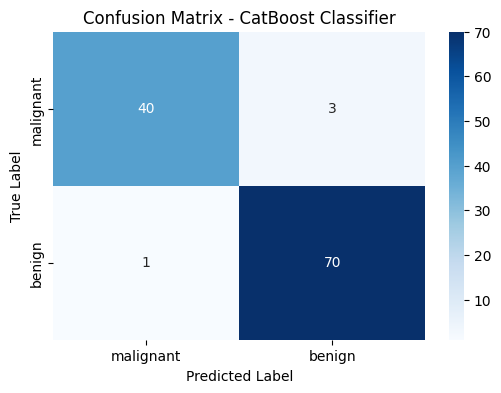

In [7]:
# Question 9: Write a Python program to:
# 1.Train a CatBoost Classifier
# 2.Plot the confusion matrix using seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier

# Step 1: Load the Breast Cancer classification dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 2: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the CatBoost Classifier
# Setting verbose=0 keeps the console output clean by hiding the training iteration logs
cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

# Step 4: Make predictions on the test data
y_pred = cat_model.predict(X_test)

# Step 5: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 6: Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()

Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
  - Data preprocessing & handling missing/categorical values
  - Choice between AdaBoost, XGBoost, or CatBoost
  - Hyperparameter tuning strategy
  - Evaluation metrics you'd choose and why
  - How the business would benefit from your model

Answer 10:
1. Data Preprocessing & Handling Missing/Categorical Values
Handling Missing Values:
    - Traditional models require manual imputation (like filling missing data with the median or using KNN). However, advanced boosting algorithms can automatically learn the best direction to send missing values during the tree-building process, saving time and preserving data integrity.
    - Handling Categorical Variables:
      - Demographic data (e.g., 'Employment Status', 'Housing Type') is categorical. Instead of using memory-heavy One-Hot Encoding, the optimal approach is to use an algorithm that natively understands categories or to apply Ordered Target Encoding.
    - Addressing the Imbalance:
      - Loan defaults are typically rare (e.g., 5% of the dataset). To stop the model from simply predicting "No Default" every time, you must apply algorithmic balancing, such as adjusting the scale_pos_weight (giving a higher penalty for missing a default) or using techniques like SMOTE to oversample the minority class.
2. Choice of Boosting Algorithm: CatBoost
    - For this specific dataset, CatBoost is the absolute best choice.
    - Why? CatBoost is explicitly engineered to handle high-cardinality categorical features natively without prior encoding. It also smoothly processes missing numeric values and has excellent built-in parameters (like auto_class_weights='Balanced') to tackle the imbalanced nature of FinTech datasets.
    - XGBoost would be a strong second choice, but it requires more manual preprocessing for the categorical demographic variables.
3. Hyperparameter Tuning Strategy
    - Instead of a slow, exhaustive Grid Search, the best strategy for a large financial dataset is using Bayesian Optimization (via a library like Optuna) or RandomizedSearchCV.
    - Key parameters to target:
    - learning_rate and iterations:
      - To balance training speed and model convergence.
    - depth:
      - Kept relatively shallow (e.g., 4 to 8) to prevent the model from overfitting to the noisy transaction behavior.
    - l2_leaf_reg:
      - L2 regularization to further prevent overfitting and handle outliers in transaction amounts.
    - scale_pos_weight (or class weights):
      - To ensure the model focuses heavily on the rare default cases.
4. Evaluation Metrics Chosen (and Why)
    - Because the dataset is imbalanced, relying on standard Accuracy is dangerous and misleading. Instead, the focus must be on the minority class:
    - Recall (Sensitivity):
      - This is the most critical metric. A high recall ensures the company catches as many actual defaulters as possible. Missing a defaulter (False Negative) costs the company a lot of money.
    - Precision-Recall AUC (PR-AUC):
      - This is highly preferred over the standard ROC-AUC for imbalanced data because it evaluates how well the model separates the specific minority class rather than the overall dataset.
    - F2-Score:
      - While the F1-Score balances Precision and Recall, an F2-Score intentionally places a higher mathematical weight on Recall, which aligns perfectly with a FinTech company's goal of minimizing financial risk.
5. How the Business Benefits
    - Direct Loss Prevention: By accurately identifying high-risk customers before the money is disbursed, the company drastically reduces its write-offs and bad debt.
    - Faster Customer Onboarding:
      - The model can instantly and confidently auto-approve low-risk applicants, providing a frictionless customer experience that beats competitors.
    - Risk-Based Pricing:
      - Instead of a flat "approve/deny," the model's output probabilities allow the company to offer tailored interest rates—giving lower rates to safe customers and charging a premium to riskier ones to offset potential losses.                  